In [239]:
import pandas as pd
import matplotlib.pyplot as plt

In [240]:
path_spend = "./data/goal_homes_spend.csv"

df_spend = pd.read_csv(path_spend, encoding="utf-8", dtype=str)

In [241]:
columns_to_keep = ["Recreación y cultura"]

In [242]:
# Dataframe Spend Total = df_s_t
df_s_t = df_spend.copy()
df_s_t.set_index("Concepto", inplace=True)
df_s_t = df_s_t.apply(lambda col: col.str.replace(".", "", regex=False))
df_s_t =df_s_t.astype(int)
df_s_t = df_s_t.T.groupby(df_s_t.columns.str.extract(r"(\d{4})", expand=False)).sum()
df_s_t.index = pd.to_datetime(df_s_t.index).year
df_s_t = df_s_t[df_s_t.index < 2026]
df_s_t = df_s_t.drop(columns=[column for column in df_s_t.columns if column not in columns_to_keep])

to_2020 = df_s_t[df_s_t.index <= 2020]
after_2020 = df_s_t[df_s_t.index >= 2020]

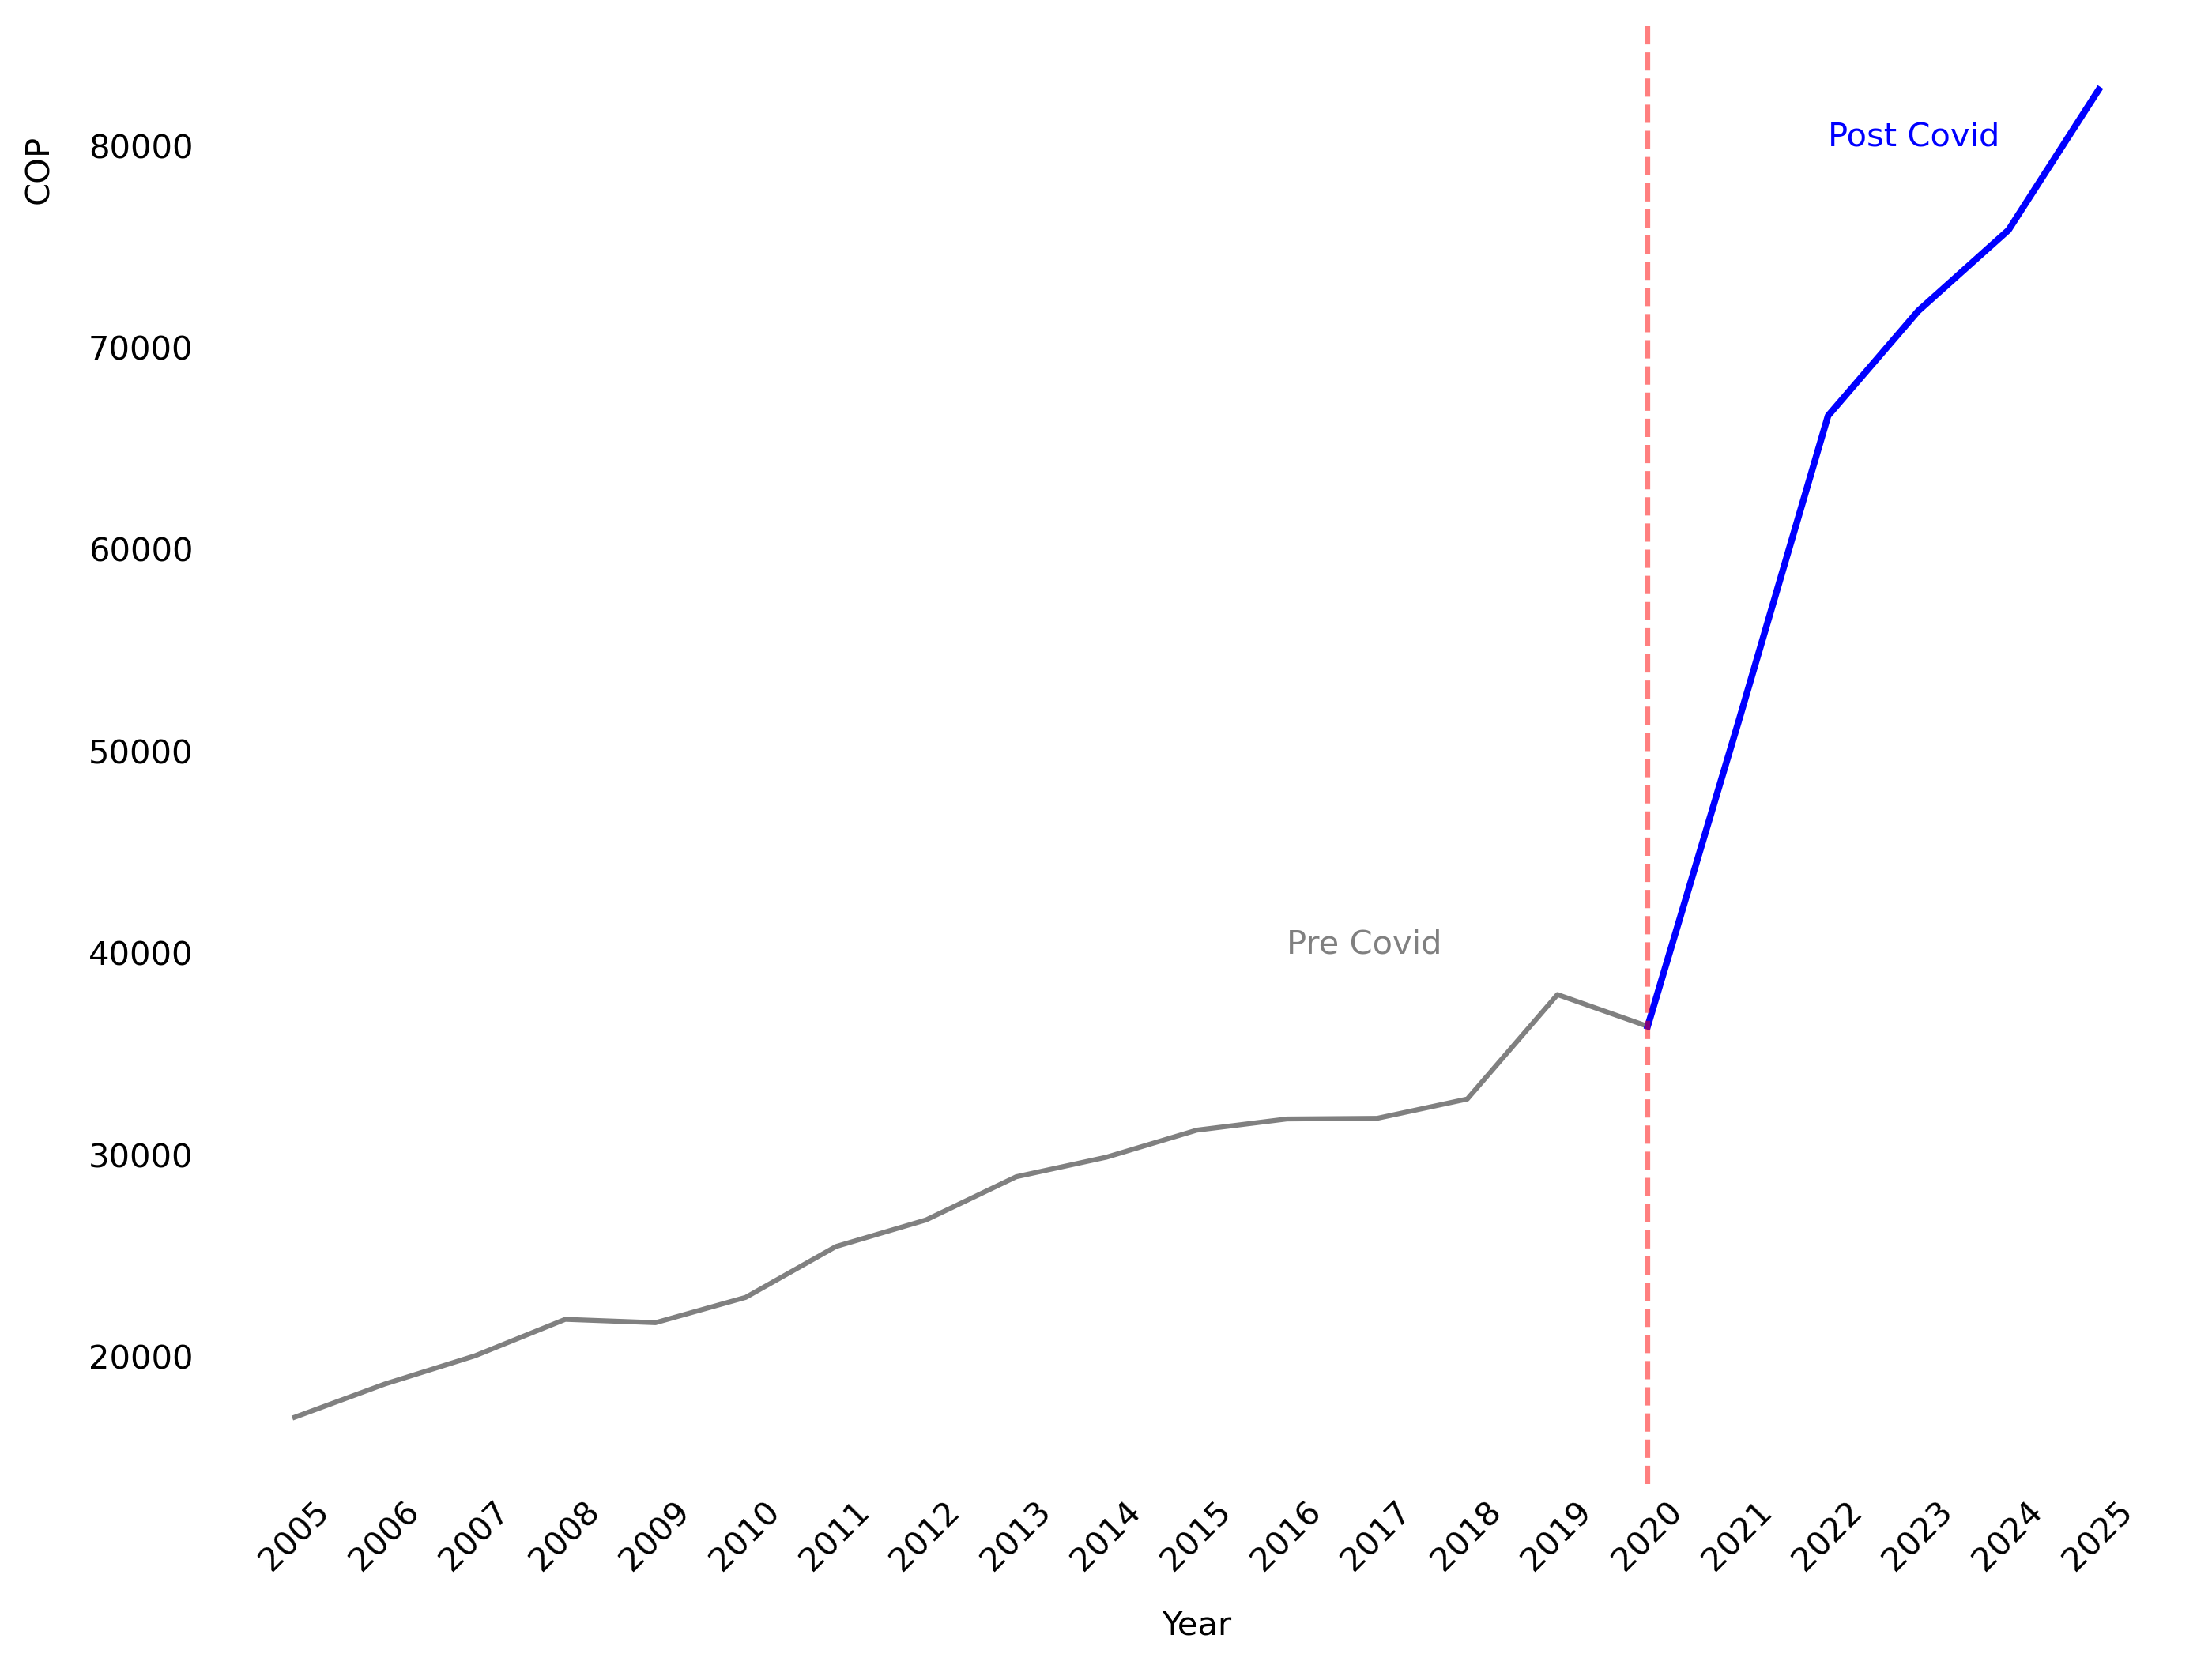

In [269]:
plt.figure(figsize=(10.8, 8), dpi=300)

plt.plot(to_2020, color="gray")
plt.plot(after_2020, color="blue", linewidth=2)

plt.xticks(df_s_t.index, rotation=45)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["bottom"].set_visible(False)
plt.gca().spines["left"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.axvline(2020, color="red", linestyle="--", alpha=0.5)

plt.text(2022, 80000, "Post Covid", color="blue")
plt.text(2016, 40000, "Pre Covid", color="Grey")

plt.tick_params(axis="y", length=0)
plt.tick_params(axis="x", length=0)

plt.ylabel("COP", labelpad=10, y=0.9)
plt.xlabel("Year", labelpad=10)

plt.show()